In [35]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

from glob import glob
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from keras import layers
from functools import partial

AUTO = tf.data.experimental.AUTOTUNE
import warnings
warnings.filterwarnings('ignore')

In [36]:
images = glob('train_cancer/*/*.jpg')
print(len(images)) 

2637


In [37]:
images = [path.replace('\\', '/') for path in images]
df = pd.DataFrame({'filepath': images})
df['label'] = df['filepath'].str.split('/', expand=True)[1]
df.head()

,filepath,label
0,train_cancer/malignant/1035.jpg,malignant
1,train_cancer/malignant/1270.jpg,malignant
2,train_cancer/malignant/144.jpg,malignant
3,train_cancer/malignant/825.jpg,malignant
4,train_cancer/malignant/1407.jpg,malignant


In [38]:
df['label_bin'] = np.where(df['label'].values == 'malignant', 1, 0)
df.head()

,filepath,label,label_bin
0,train_cancer/malignant/1035.jpg,malignant,1
1,train_cancer/malignant/1270.jpg,malignant,1
2,train_cancer/malignant/144.jpg,malignant,1
3,train_cancer/malignant/825.jpg,malignant,1
4,train_cancer/malignant/1407.jpg,malignant,1


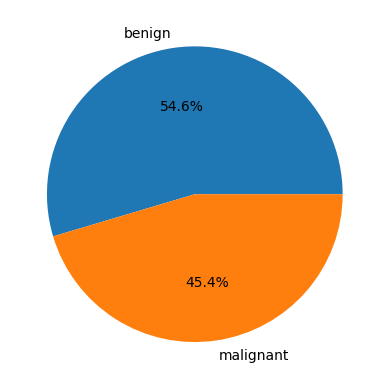

In [39]:
x = df['label'].value_counts()
plt.pie(x.values, labels=x.index, autopct='%1.1f%%')
plt.show()

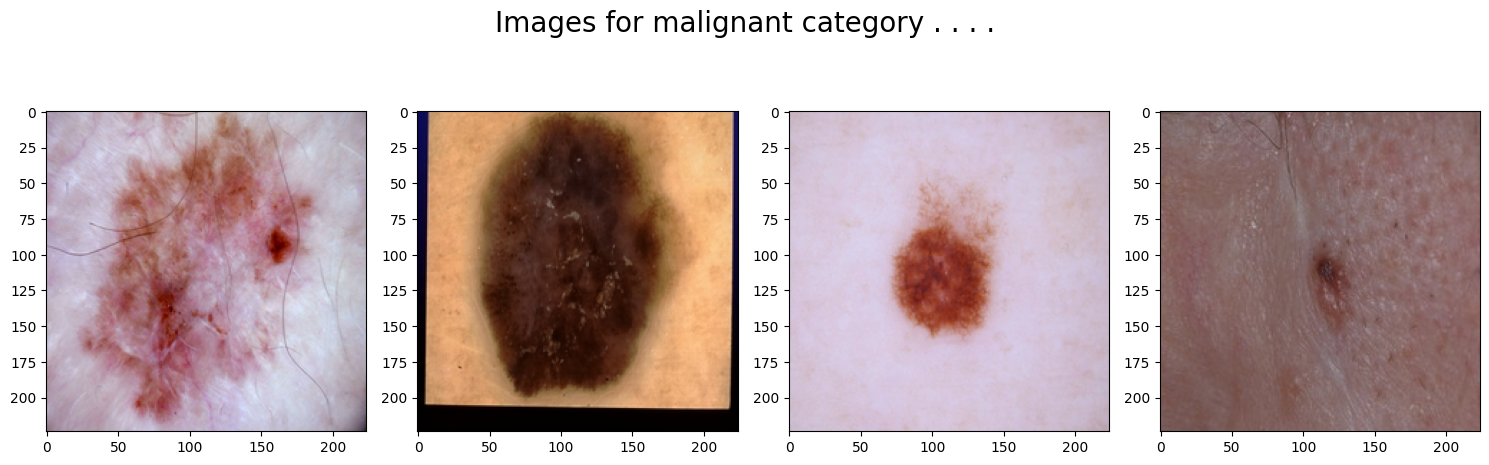

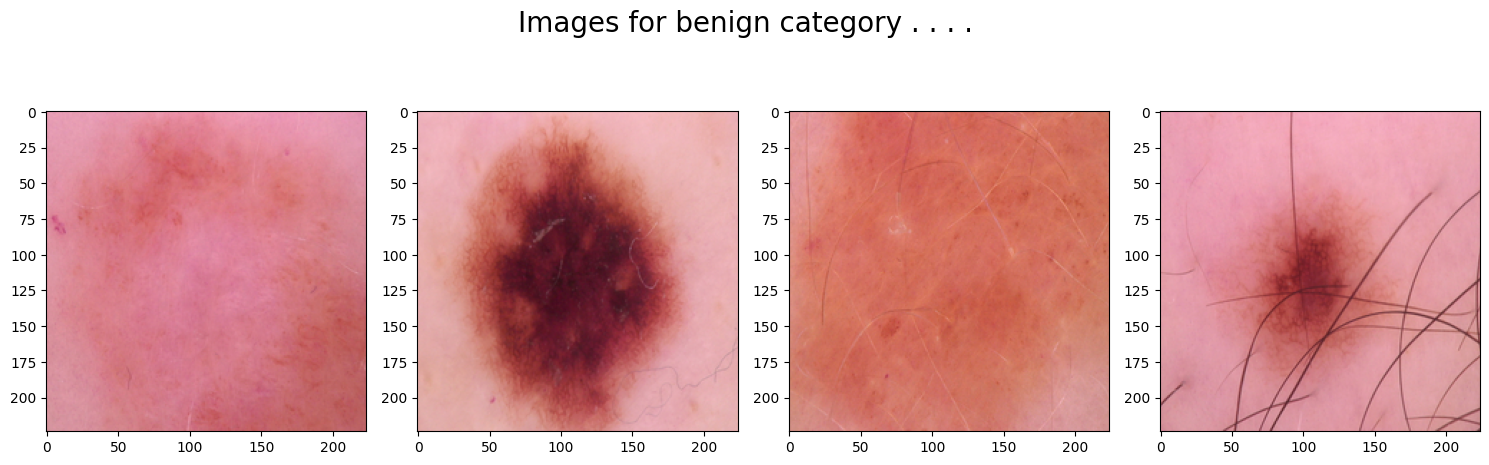

In [40]:
for cat in df['label'].unique():
    temp = df[df['label'] == cat]
    index_list = temp.index
    fig, ax = plt.subplots(1, 4, figsize=(15, 5))
    fig.suptitle(f'Images for {cat} category . . . .', fontsize=20)
    for i in range(4):
        index = np.random.randint(0, len(index_list))
        index = index_list[index]
        data = df.iloc[index]
        image_path = data['filepath']
        img = np.array(Image.open(image_path))
        ax[i].imshow(img)
    plt.tight_layout()
    plt.show()

In [41]:
features = df['filepath']
target = df['label_bin']

X_train, X_val, Y_train, Y_val = train_test_split(
    features, target,
    test_size=0.15,
    random_state=10
)

print(X_train.shape, X_val.shape)

(2241,) (396,)


In [42]:
def decode_image(filepath, label=None):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0

    if label == 0:
        Label = 0
    else:
        Label = 1

    return img, Label

In [43]:
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, Y_train))
    .map(decode_image, num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, Y_val))
    .map(decode_image, num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

In [44]:
from tensorflow.keras.applications.efficientnet import EfficientNetB7

pre_trained_model = EfficientNetB7(
    input_shape=(224, 224, 3),
    weights='imagenet',
    include_top=False
)

for layer in pre_trained_model.layers:
    layer.trainable = False

In [45]:
from tensorflow.keras import Model

inputs = layers.Input(shape=(224, 224, 3))
x = layers.Flatten()(inputs)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    38,535,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,603,521 (147.26 MB)

 Trainable params: 38,602,497 (147.26 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [46]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['AUC']
)

In [47]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

Epoch 1/5


71/71 ━━━━━━━━━━━━━━━━━━━━ 73s 724ms/step - AUC: 0.8264 - loss: 0.5369 - val_AUC: 0.7709 - val_loss: 1.9266
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 50s 702ms/step - AUC: 0.8550 - loss: 0.4806 - val_AUC: 0.8395 - val_loss: 1.1518
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - AUC: 0.8621 - loss: 0.4632 - val_AUC: 0.8787 - val_loss: 0.4642
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 92s 659ms/step - AUC: 0.8795 - loss: 0.4352 - val_AUC: 0.8757 - val_loss: 1.1911
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 81s 648ms/step - AUC: 0.8937 - loss: 0.4065 - val_AUC: 0.8960 - val_loss: 0.4064


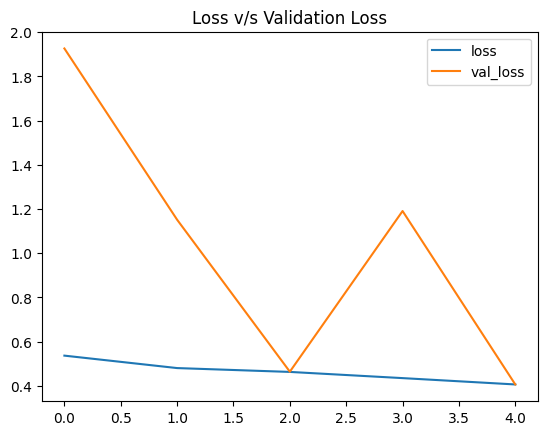

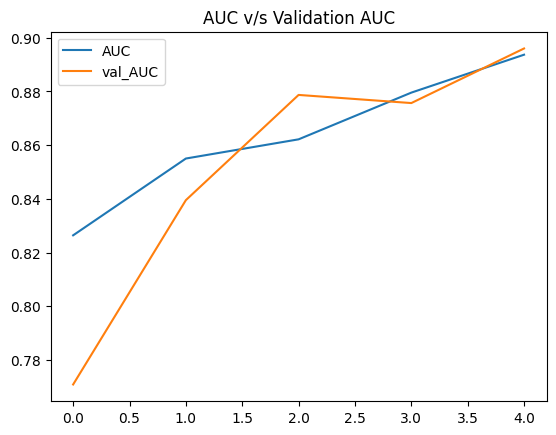

In [48]:
hist_df = pd.DataFrame(history.history)

plt.plot(hist_df['loss'], label='loss')
plt.plot(hist_df['val_loss'], label='val_loss')
plt.title('Loss v/s Validation Loss')
plt.legend()
plt.show()

plt.plot(hist_df['AUC'], label='AUC')
plt.plot(hist_df['val_AUC'], label='val_AUC')
plt.title('AUC v/s Validation AUC')
plt.legend()
plt.show()